# License Plate Matching 


In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import os

# Configuration
TRAIN_FOLDER = "Train"
QUERY_FOLDER = "License Plates"

In [2]:
# List train images
train_files = [f for f in os.listdir(TRAIN_FOLDER) if f.endswith(('.png', '.jpg', '.jpeg'))]

# List query images
query_files = [f for f in os.listdir(QUERY_FOLDER) if f.endswith(('.png', '.jpg', '.jpeg'))]

# Initiate SIFT detector
sift = cv2.SIFT_create()


[1/35] Vehicle: b15d6c0bdf90226d_jpg.rf.775557ba6aaf7d76a8d4bb04f66d8fc5.jpg
Query keypoints detected: 1513

[2/35] Vehicle: b193070a9c45b5ab_jpg.rf.57e5987eb896a7bf9fc7a1a96a660c7e.jpg
Query keypoints detected: 810

[3/35] Vehicle: b1a50a3824887ee2_jpg.rf.68a4fd34fce20184287592f2680f895b.jpg
Query keypoints detected: 1187

[4/35] Vehicle: b25d7d2cb7abf86b_jpg.rf.36edce738b0e69965e001035d6f85ab3.jpg
Query keypoints detected: 483

[5/35] Vehicle: b32671b7cc279583_jpg.rf.f898026e2169a3b6adc4d21aee6d06c5.jpg
Query keypoints detected: 470

[6/35] Vehicle: b3b61da98e22cd4a_jpg.rf.e5f31065702d60c5746652895714f770.jpg
Query keypoints detected: 1278

[7/35] Vehicle: b5e7183b6a5abe6c_jpg.rf.fa89af80aebfc925bb0121ab5b024260.jpg
Query keypoints detected: 1093

[8/35] Vehicle: b6580dec5ada277d_jpg.rf.3ec17c0d68df1e6818d590e410bc3d00.jpg
Query keypoints detected: 433

[9/35] Vehicle: b6e55f97085c3732_jpg.rf.09a6d8dc1a08e66131bdb8b57377b05b.jpg
Query keypoints detected: 1027

[10/35] Vehicle: b6ecd

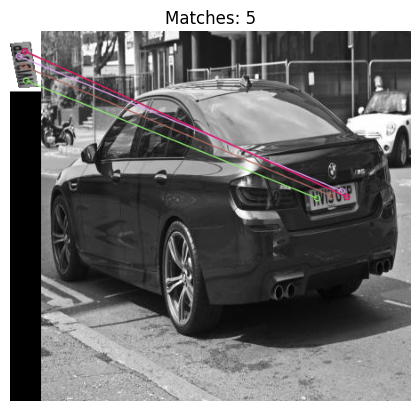


[12/35] Vehicle: b8a3f2ea385e45b3_jpg.rf.1b19b61606bd9199fa0f774c35cf8986.jpg
Query keypoints detected: 2004

[13/35] Vehicle: b91c3aaba25bf914_jpg.rf.1f03184f0c412a59b83c4099861cedcf.jpg
Query keypoints detected: 1266

[14/35] Vehicle: b94993a2d67b455e_jpg.rf.62712d980344cb842644f82e63b13092.jpg
Query keypoints detected: 1977

[15/35] Vehicle: b9f5b9acf1777acf_jpg.rf.b92969d5c3738ece6a84dcd2d0ea3ce0.jpg
Query keypoints detected: 592

[16/35] Vehicle: bbcac63e32bd8137_jpg.rf.ef4704b0ada4fbbf613143abf52f6f86.jpg
Query keypoints detected: 876

[17/35] Vehicle: bd12ea92bcab1afd_jpg.rf.fe51aa4c3da615ae6656ea88fc7250e3.jpg
Query keypoints detected: 1398

[18/35] Vehicle: be654a7eabe0e891_jpg.rf.5e43d4106641423a278d096d24822902.jpg
Query keypoints detected: 774


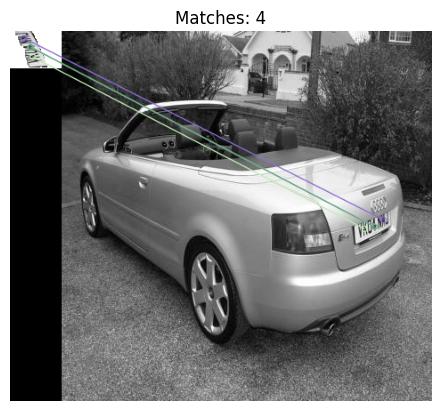


[19/35] Vehicle: be9fd0014b5a4f2a_jpg.rf.20dc7369d0a83ad74a123727228dce11.jpg
Query keypoints detected: 429


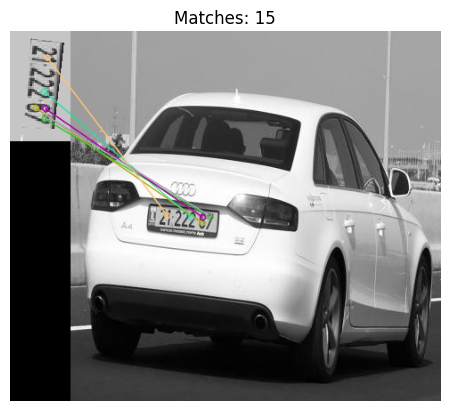


[20/35] Vehicle: bf0aac0878b0a3d2_jpg.rf.43ce523ba85e649db07055557d72cc9e.jpg
Query keypoints detected: 875

[21/35] Vehicle: bf2f25f3ed9ff4d5_jpg.rf.e9d07ec8b85372d40366bc2770b7d537.jpg
Query keypoints detected: 587

[22/35] Vehicle: c1d8b110186e095a_jpg.rf.1515701021c709417f9e92537a1d3714.jpg
Query keypoints detected: 912

[23/35] Vehicle: c274e026ac907eb9_jpg.rf.2388de7229ba0dd3051326f64c1a770b.jpg
Query keypoints detected: 380

[24/35] Vehicle: c650ff8d3e8e75b3_jpg.rf.a469a8f0edb8fddf8e2b70b102f5a5eb.jpg
Query keypoints detected: 878

[25/35] Vehicle: c7df5232291486a3_jpg.rf.d18b52a383576cfe6c4ec343fca07a80.jpg
Query keypoints detected: 737


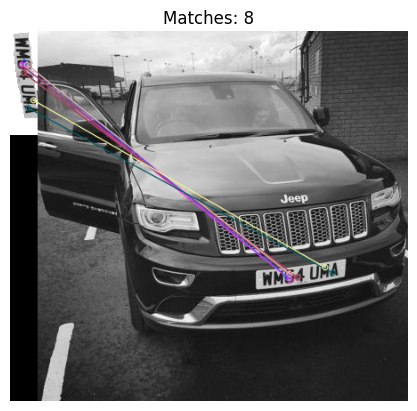


[26/35] Vehicle: c91ee912164d8ecb_jpg.rf.5a70d8b40bde25a3a4cb09337bf0c6f9.jpg
Query keypoints detected: 726

[27/35] Vehicle: cb4b754537798d23_jpg.rf.310e3c4544bf89d2f3109956b301db20.jpg
Query keypoints detected: 1466

[28/35] Vehicle: cb8c75fc1c7ccf73_jpg.rf.a6d315cf4a3ef0824075df8c8561838b.jpg
Query keypoints detected: 1008

[29/35] Vehicle: ccc1a2d44a290368_jpg.rf.8e8d6f87f1d1327caf5f80e0c96cdad9.jpg
Query keypoints detected: 1219

[30/35] Vehicle: cdb1e8621d1c624e_jpg.rf.b744b93a7af0771f1e5cb955155c8451.jpg
Query keypoints detected: 433

[31/35] Vehicle: ce97f7bc90e97109_jpg.rf.0ee971ca2acc7c8826290a5a80153777.jpg
Query keypoints detected: 1246

[32/35] Vehicle: d027c6e32db60e3c_jpg.rf.15a865d02f390ef84fca8e053946db31.jpg
Query keypoints detected: 594

[33/35] Vehicle: d27e094e98374ff8_jpg.rf.a0e0eba539117b97eb6433295c4cfb44.jpg
Query keypoints detected: 1071

[34/35] Vehicle: d28d71c2690c16ed_jpg.rf.b7c4b2a5e5870d9fcf8644c109c5457f.jpg
Query keypoints detected: 1372


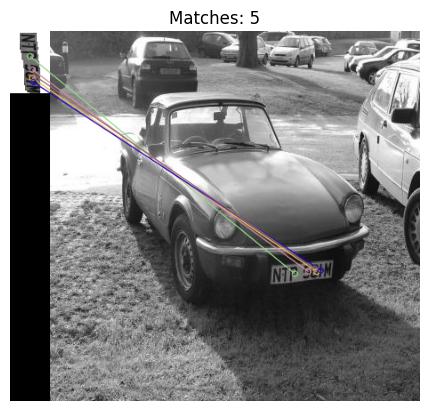


[35/35] Vehicle: d2fe2b47668e9d8e_jpg.rf.c3c019d146ec1fc0bcf7fbeb12c7bc7f.jpg
Query keypoints detected: 985


In [3]:
# Store results
all_results = []

bf = cv2.BFMatcher()

for query_idx, query_file in enumerate(query_files, 1):
    print(f"\n{'='*80}")
    print(f"[{query_idx}/{len(query_files)}] Vehicle: {query_file}") # print wsh mn vehicue rana
    print(f"{'='*80}")
    
    # telecharger image voiture 
    query_path = os.path.join(QUERY_FOLDER, query_file)
    img1 = cv2.imread(query_path, 0)  
        
    # trouver les keypoints 
    kp1, des1 = sift.detectAndCompute(img1, None)
   
    print(f"Query keypoints detected: {len(kp1)}")

    query_results = {}
    best_match = None
    best_train_data = None
    
    # Matcher avec image train 
    for train_idx, train_file in enumerate(train_files, 1): # On boucle sur train 
        train_path = os.path.join(TRAIN_FOLDER, train_file)
        img2 = cv2.imread(train_path, 0)  # lire les images
     
       
        # Find keypoints and descriptors for train (using blurred image)
        kp2, des2 = sift.detectAndCompute(img2, None)
        
        
        # BFMatcher with default params
        matches = bf.knnMatch(des2, des1, k=2) # ca retourne best 2 matches 
        #k=2 pour knnMatch, on veut les 2 meilleurs matches pour appliquer le ratio test de Lowe
       
        good = [m for m, n in matches if m.distance < 0.65 * n.distance]

        
        num_matches = len(good)
        
        # Keep track of best match
        if num_matches >= 4:
            img_match = cv2.drawMatches(img2, kp2, img1, kp1, good[:10], None, flags=2)
            plt.imshow(img_match), plt.title(f"Matches: {num_matches}"), plt.axis('off')
            plt.show()

    